# Marine 48h Forecast — SOFTS (STAR Module) Ablation (18 "good" parameters)

Tests [SOFTS: Efficient Multivariate Time Series Forecasting with Series-Core Fusion](https://arxiv.org/abs/2404.14197)
(NeurIPS 2024) against the existing iTransformer baseline, restricted to the 18 parameters
iTransformer already handles well (the hard 6 are out of scope — see the v1-v5 hybrid notebooks).

**The idea:** SOFTS replaces iTransformer's full cross-variate self-attention with a much simpler
**STAR (STar Aggregate-Redistribute) module**: each channel's embedding is projected through an MLP,
pooled into a single shared "core" representation via **stochastic pooling** (softmax-weighted random
sampling per feature dimension during training; the softmax-weighted *expectation* at inference — a
known regularizer, akin to stochastic pooling in CNNs), then the core is broadcast back and fused with
each channel via a second MLP with a residual connection. No attention at all.

**Why this is worth testing here, specifically:** the paper's main selling point is *efficiency*
(linear, not quadratic, scaling with channel count) — irrelevant at our scale (24-27 channels). What
*is* relevant: it's a fundamentally different inductive bias than attention — MLP-based mixing through
a shared bottleneck core, with a built-in stochastic regularizer, rather than full pairwise attention.
That regularization could matter on a 28-day dataset where the Dual-Channel ablation already showed
that *unconstrained* added capacity (more attention-adjacent parameters) doesn't reliably help.
SOFTS isn't "more capacity" — it's a different, smaller-footprint way to mix channels.

Faithful reimplementation of the paper's STAR module (Section 3.2): per-channel linear embedding,
`MLP_1` projection, stochastic pooling across channels, repeat-concat with each channel, `MLP_2` fusion
with residual connection, stacked for `N` layers, final linear projection to the horizon.

Standalone — does not modify any other notebook, dashboard, or CSV in this project.

## 0. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")
torch.set_num_threads(8)

print("PyTorch:", torch.__version__, "| torch threads:", torch.get_num_threads())

PyTorch: 2.12.1+cpu | torch threads: 8


## 1. Load data, collapse duplicates, encode circular parameters

In [2]:
df_10min = pd.read_csv("ems_10min_resampled.csv", index_col=0, parse_dates=True)
DUPLICATES = [
    ("airTemperature", "windChillTemperature"),
    ("tideLevel", "tidePressure"),
    ("tideLevel", "waterPressure"),
    ("tideLevel", "waterLevel"),
    ("waterTemperature", "waterTemperature_WQ"),
    ("significantWaveHeight", "maxWaveHeight"),
]
df_cat = df_10min[["precipitationType"]].copy()
df_num = df_10min.drop(columns=["precipitationType"]).copy()

CIRCULAR = ["windDirection", "currentDirection", "compass"]
for c in CIRCULAR:
    rad = np.deg2rad(df_num[c])
    df_num[f"{c}_sin"] = np.sin(rad)
    df_num[f"{c}_cos"] = np.cos(rad)
df_num_full = df_num.drop(columns=CIRCULAR)

target_cols = [c for c in df_num_full.columns if c not in [d for _, d in DUPLICATES]]

PRECIP_PARAMS = ["precipitationIntensity", "precipitationDifference"]
VISIBILITY_PARAMS = ["twentyFourHourAvgVisibility", "tenMinuteAvgVisibility",
                      "oneMinuteAvgVisibility", "oneHourAvgVisibility"]
HARD_PARAMS = PRECIP_PARAMS + VISIBILITY_PARAMS
GOOD_PARAMS = [c for c in target_cols if c not in HARD_PARAMS]
print(f"This ablation covers the {len(GOOD_PARAMS)} 'good' parameters only: {GOOD_PARAMS}")

This ablation covers the 21 'good' parameters only: ['airTemperature', 'airPressure', 'relativeHumidity', 'dewPointTemperature', 'windSpeed', 'globalRadiation', 'currentSpeed', 'tideLevel', 'waterTemperature', 'conductivity', 'salinity', 'significantWaveHeight', 'significantWavePeriod', 'peakWaveEnergyPeriod', 'zeroCrossingPeriod', 'windDirection_sin', 'windDirection_cos', 'currentDirection_sin', 'currentDirection_cos', 'compass_sin', 'compass_cos']


## 2. Train/test split, duplicate reconstruction fit, scaling

In [3]:
LOOKBACK, HORIZON = 288, 288   # 2 days lookback, 48h horizon @ 10-min steps

idx = df_num_full.index
df_num_full["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
df_num_full["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
df_num_full["dom_sin"] = np.sin(2 * np.pi * idx.day / 30)
df_num_full["dom_cos"] = np.cos(2 * np.pi * idx.day / 30)
calendar_cols = ["hour_sin", "hour_cos", "dom_sin", "dom_cos"]

feature_cols = target_cols + calendar_cols
model_data = df_num_full[feature_cols].copy()
n_features = len(feature_cols)
good_idx = [feature_cols.index(c) for c in GOOD_PARAMS]

train_df = model_data.iloc[:-HORIZON].copy()
test_df = model_data.iloc[-HORIZON:].copy()
mean, std = train_df.mean(), train_df.std().replace(0, 1)
train_scaled = (train_df - mean) / std

print(f"Train: {train_df.shape[0]} rows ({train_df.shape[0]/144:.1f} days)")
print(f"Test : {test_df.shape[0]} rows ({test_df.shape[0]/144:.1f} days)")

Train: 4032 rows (28.0 days)
Test : 288 rows (2.0 days)


In [4]:
recon_coef = {}
for keep, drop in DUPLICATES:
    x, y = train_df[keep].values, df_num_full[drop].iloc[:-HORIZON].values
    slope, intercept = np.polyfit(x, y, 1)
    pred_train = slope * x + intercept
    r2 = 1 - np.sum((y - pred_train) ** 2) / np.sum((y - y.mean()) ** 2)
    recon_coef[drop] = (keep, float(slope), float(intercept), float(r2))

## 3. Shared training data and training loop

In [5]:
def make_direct_windows(scaled_df, lookback, horizon, out_idx):
    arr = scaled_df.values.astype(np.float32)
    X, Y = [], []
    for origin in range(lookback, len(arr) - horizon):
        X.append(arr[origin - lookback:origin])
        Y.append(arr[origin:origin + horizon][:, out_idx])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_direct, Y_good = make_direct_windows(train_scaled, LOOKBACK, HORIZON, good_idx)
X_t, Y_good_t = torch.from_numpy(X_direct), torch.from_numpy(Y_good)
n_val = max(1, int(0.1 * len(X_t)))
X_tr, Y_tr = X_t[:-n_val], Y_good_t[:-n_val]
X_val, Y_val = X_t[-n_val:], Y_good_t[-n_val:]
last_window = torch.from_numpy(train_scaled.values[-LOOKBACK:].astype(np.float32)).unsqueeze(0)


def train_model(model, X_tr, Y_tr, X_val, Y_val, epochs=150, batch_size=64, lr=1e-3,
                 patience=20, name=""):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=6)
    loss_fn = nn.MSELoss()
    best_val, best_state, wait = float("inf"), None, 0
    n = len(X_tr); t0 = time.time()
    for ep in range(epochs):
        ep_t0 = time.time()
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            b = perm[i:i + batch_size]
            xb, yb = X_tr[b].to(device), Y_tr[b].to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val.to(device)), Y_val.to(device)).item()
        sched.step(val_loss)
        print(f"  [{name}] epoch {ep+1:3d}/{epochs}  val_loss={val_loss:.4f}  "
              f"epoch_time={time.time()-ep_t0:.1f}s  elapsed={time.time()-t0:.0f}s", flush=True)
        if val_loss < best_val - 1e-5:
            best_val, wait = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    model.eval()
    print(f"{name:14s} best_val_loss={best_val:.4f}  epochs_run={ep+1:3d}  time={time.time()-t0:5.1f}s")
    return model

## 4. Model A — Baseline iTransformer (channel-dependent attention, unchanged architecture)

In [6]:
class ITransformer(nn.Module):
    def __init__(self, lookback, n_features, horizon, out_idx, d_model=64, n_heads=4,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.out_idx = out_idx
        self.embed = nn.Linear(lookback, d_model)
        self.var_id = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 2,
                                            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        tok = self.embed(x.transpose(1, 2)) + self.var_id.unsqueeze(0)
        tok = self.encoder(tok)
        out = self.head(tok)
        return out.transpose(1, 2)[:, :, self.out_idx]

baseline = ITransformer(LOOKBACK, n_features, HORIZON, good_idx, d_model=64, n_heads=4, n_layers=2)
baseline = train_model(baseline, X_tr, Y_tr, X_val, Y_val, epochs=150, patience=20, name="Baseline-iTransformer")

with torch.no_grad():
    baseline_pred_scaled = baseline(last_window.to(device))[0].cpu().numpy()
baseline_preds_real = baseline_pred_scaled * std[GOOD_PARAMS].values + mean[GOOD_PARAMS].values
baseline_pred_df = pd.DataFrame(baseline_preds_real, columns=GOOD_PARAMS, index=test_df.index)
print("Baseline iTransformer 48h forecast complete.")

  [Baseline-iTransformer] epoch   1/150  val_loss=0.4280  epoch_time=0.9s  elapsed=1s


  [Baseline-iTransformer] epoch   2/150  val_loss=0.3269  epoch_time=0.8s  elapsed=2s


  [Baseline-iTransformer] epoch   3/150  val_loss=0.2639  epoch_time=0.8s  elapsed=2s


  [Baseline-iTransformer] epoch   4/150  val_loss=0.2357  epoch_time=1.0s  elapsed=3s


  [Baseline-iTransformer] epoch   5/150  val_loss=0.2015  epoch_time=0.8s  elapsed=4s


...

  [Baseline-iTransformer] epoch 147/150  val_loss=0.0368  epoch_time=2.4s  elapsed=305s


  [Baseline-iTransformer] epoch 148/150  val_loss=0.0366  epoch_time=1.1s  elapsed=306s


  [Baseline-iTransformer] epoch 149/150  val_loss=0.0367  epoch_time=1.0s  elapsed=307s


  [Baseline-iTransformer] epoch 150/150  val_loss=0.0365  epoch_time=0.9s  elapsed=308s


Baseline-iTransformer best_val_loss=0.0365  epochs_run=150  time=308.2s
Baseline iTransformer 48h forecast complete.


## 5. Model B — SOFTS (STAR module: MLP-based core fusion, no attention)
Faithful to the paper: per-channel `MLP_1` projection, softmax-weighted stochastic pooling across channels into a single shared core (sampled during training, expectation at inference), repeat-concat back with each channel, `MLP_2` fusion with a residual connection, stacked `N` layers.

In [7]:
class STARModule(nn.Module):
    def __init__(self, d_model, d_core):
        super().__init__()
        self.mlp1 = nn.Sequential(nn.Linear(d_model, d_model), nn.GELU(), nn.Linear(d_model, d_core))
        self.mlp2 = nn.Sequential(nn.Linear(d_model + d_core, d_model), nn.GELU(), nn.Linear(d_model, d_model))

    def forward(self, S):                                  # S: (B, C, d_model)
        A = self.mlp1(S)                                    # (B, C, d_core)
        p = torch.softmax(A, dim=1)                          # softmax over channels, per feature dim
        if self.training:
            B, C, d_core = A.shape
            p_flat = p.permute(0, 2, 1).reshape(B * d_core, C)
            idx = torch.multinomial(p_flat, 1).squeeze(-1)
            A_flat = A.permute(0, 2, 1).reshape(B * d_core, C)
            o = A_flat.gather(1, idx.unsqueeze(1)).squeeze(1).reshape(B, d_core)
        else:
            o = (p * A).sum(dim=1)                           # expectation under the same softmax weights
        o_rep = o.unsqueeze(1).expand(-1, S.shape[1], -1)     # broadcast the shared core back to every channel
        F = torch.cat([S, o_rep], dim=-1)
        return self.mlp2(F) + S                               # residual fusion


class SOFTS(nn.Module):
    def __init__(self, lookback, n_features, horizon, out_idx, d_model=64, d_core=64,
                 n_layers=2, dropout=0.1):
        super().__init__()
        self.out_idx = out_idx
        self.embed = nn.Linear(lookback, d_model)
        self.layers = nn.ModuleList([STARModule(d_model, d_core) for _ in range(n_layers)])
        self.head = nn.Linear(d_model, horizon)

    def forward(self, x):
        S = self.embed(x.transpose(1, 2))                    # (B, n_features, d_model)
        for layer in self.layers:
            S = layer(S)
        out = self.head(S)
        return out.transpose(1, 2)[:, :, self.out_idx]

softs = SOFTS(LOOKBACK, n_features, HORIZON, good_idx, d_model=64, d_core=64, n_layers=2)
softs = train_model(softs, X_tr, Y_tr, X_val, Y_val, epochs=150, patience=20, name="SOFTS")

with torch.no_grad():
    softs_pred_scaled = softs(last_window.to(device))[0].cpu().numpy()
softs_preds_real = softs_pred_scaled * std[GOOD_PARAMS].values + mean[GOOD_PARAMS].values
softs_pred_df = pd.DataFrame(softs_preds_real, columns=GOOD_PARAMS, index=test_df.index)
print("SOFTS 48h forecast complete.")

  [SOFTS] epoch   1/150  val_loss=0.4182  epoch_time=0.4s  elapsed=0s


  [SOFTS] epoch   2/150  val_loss=0.3865  epoch_time=0.5s  elapsed=1s


  [SOFTS] epoch   3/150  val_loss=0.3525  epoch_time=0.4s  elapsed=1s


  [SOFTS] epoch   4/150  val_loss=0.2766  epoch_time=0.4s  elapsed=2s


  [SOFTS] epoch   5/150  val_loss=0.1975  epoch_time=0.4s  elapsed=2s


...

  [SOFTS] epoch 124/150  val_loss=0.0537  epoch_time=0.4s  elapsed=62s


  [SOFTS] epoch 125/150  val_loss=0.0534  epoch_time=0.4s  elapsed=63s


  [SOFTS] epoch 126/150  val_loss=0.0535  epoch_time=0.4s  elapsed=63s


  [SOFTS] epoch 127/150  val_loss=0.0538  epoch_time=0.4s  elapsed=64s


SOFTS          best_val_loss=0.0532  epochs_run=127  time= 63.5s
SOFTS 48h forecast complete.


## 6. The verdict: does the STAR module beat iTransformer's attention, parameter by parameter?

In [8]:
def reconstruct(pred_df_in):
    out = pred_df_in.copy()
    for ang in ["windDirection", "currentDirection", "compass"]:
        if f"{ang}_sin" in out.columns:
            out[ang] = (np.rad2deg(np.arctan2(out[f"{ang}_sin"], out[f"{ang}_cos"])) % 360)
    return out

baseline_final = reconstruct(baseline_pred_df)
softs_final = reconstruct(softs_pred_df)
truth = df_num_full.iloc[-HORIZON:].copy()
for ang in ["windDirection", "currentDirection", "compass"]:
    truth[ang] = (np.rad2deg(np.arctan2(truth[f"{ang}_sin"], truth[f"{ang}_cos"])) % 360)

report_params = [c for c in GOOD_PARAMS if not c.endswith(("_sin", "_cos"))] + \
                [a for a in ["windDirection", "currentDirection", "compass"] if f"{a}_sin" in GOOD_PARAMS]
CIRCULAR_PARAMS = {"windDirection", "currentDirection", "compass"}

def circ_mae(true, pred):
    return np.abs((true - pred + 180) % 360 - 180).mean()

last_obs = df_num_full.iloc[-HORIZON - 1]
for ang in ["windDirection", "currentDirection", "compass"]:
    last_obs[ang] = (np.rad2deg(np.arctan2(last_obs[f"{ang}_sin"], last_obs[f"{ang}_cos"])) % 360)

metrics = []
for p in report_params:
    yt = truth[p].values
    yp_persist = np.repeat(last_obs[p], HORIZON)
    is_circular = p in CIRCULAR_PARAMS
    mae_p = circ_mae(yt, yp_persist) if is_circular else mean_absolute_error(yt, yp_persist)

    yb, ys = baseline_final[p].values, softs_final[p].values
    if is_circular:
        mae_b, mae_s = circ_mae(yt, yb), circ_mae(yt, ys)
    else:
        mae_b, mae_s = mean_absolute_error(yt, yb), mean_absolute_error(yt, ys)

    skill_b = (1 - mae_b / mae_p) * 100 if mae_p > 0 else np.nan
    skill_s = (1 - mae_s / mae_p) * 100 if mae_p > 0 else np.nan
    metrics.append({
        "parameter": p, "Persistence_MAE": round(mae_p, 4),
        "iTransformer_MAE": round(mae_b, 4), "iTransformer_skill_%": round(skill_b, 1),
        "SOFTS_MAE": round(mae_s, 4), "SOFTS_skill_%": round(skill_s, 1),
        "improvement_pp": round(skill_s - skill_b, 1),
    })

metrics_df = pd.DataFrame(metrics).sort_values("improvement_pp", ascending=False).reset_index(drop=True)
n_improved = int((metrics_df["improvement_pp"] > 0).sum())
mean_delta = metrics_df["improvement_pp"].mean()
mean_softs = metrics_df["SOFTS_skill_%"].mean()
mean_itransformer = metrics_df["iTransformer_skill_%"].mean()
print(metrics_df.to_string(index=False))
print(f"\nSOFTS improves {n_improved}/{len(metrics_df)} parameters | mean delta = {mean_delta:+.2f}pp")
print(f"Mean skill -- SOFTS: {mean_softs:+.1f}%  iTransformer: {mean_itransformer:+.1f}%")
if n_improved > len(metrics_df) / 2 and mean_delta > 0:
    print("VERDICT: SOFTS beats iTransformer -- majority improvement, positive mean delta. Worth a dashboard.")
else:
    print("VERDICT: keep the baseline iTransformer -- no clear majority benefit from the STAR module.")

            parameter  Persistence_MAE  iTransformer_MAE  iTransformer_skill_%  SOFTS_MAE  SOFTS_skill_%  improvement_pp
     currentDirection          91.7282            3.6898                  96.0     3.7017           96.0            -0.0
        windDirection          73.1616            2.2917                  96.9     2.7343           96.3            -0.6
 peakWaveEnergyPeriod           0.3262            0.1336                  59.0     0.1364           58.2            -0.8
            windSpeed           2.1258            0.2232                  89.5     0.2417           88.6            -0.9
             salinity           0.3496            0.0439                  87.5     0.0471           86.5            -0.9
     relativeHumidity          18.7896            0.6970                  96.3     0.8984           95.2            -1.1
       airTemperature           5.8458            0.1163                  98.0     0.2114           96.4            -1.6
  dewPointTemperature           

## 7. Plot a few parameters, baseline vs SOFTS vs actual

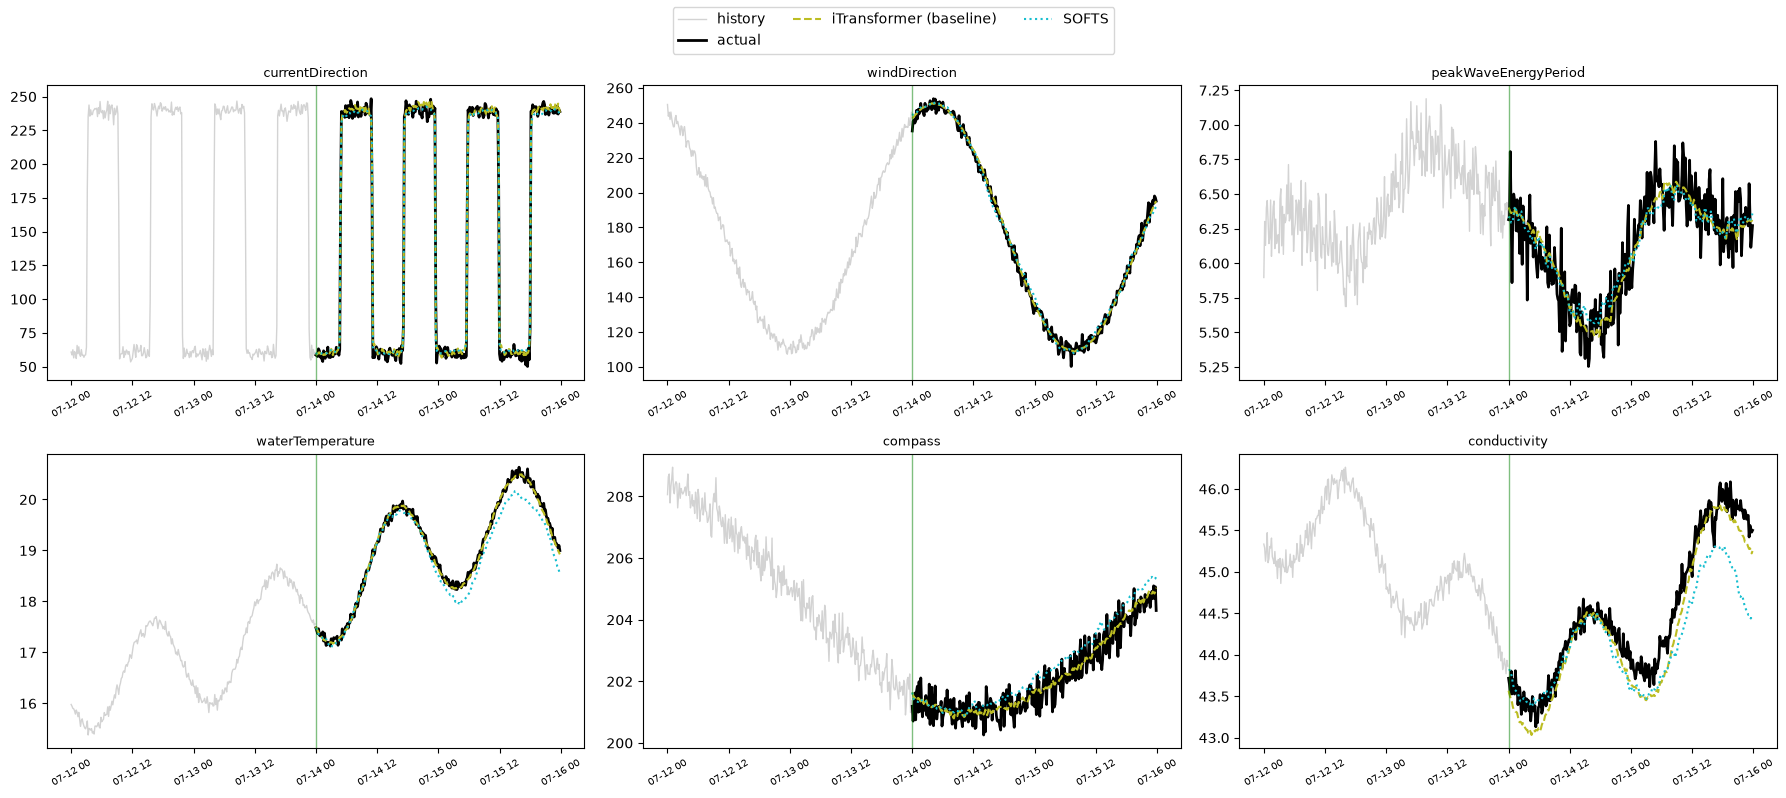

Saved softs_ablation_plot.png  (top 3 = biggest SOFTS gains, bottom 3 = biggest SOFTS losses)


In [9]:
plot_params = metrics_df["parameter"].head(3).tolist() + metrics_df["parameter"].tail(3).tolist()
hist_tail = df_10min.iloc[-HORIZON - LOOKBACK:-HORIZON]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, c in zip(axes.ravel(), plot_params):
    ax.plot(hist_tail.index, hist_tail[c], color="lightgray", lw=1, label="history")
    ax.plot(truth.index, truth[c], color="black", lw=2, label="actual")
    ax.plot(truth.index, baseline_final[c], color="#bcbd22", lw=1.5, ls="--", label="iTransformer (baseline)")
    ax.plot(truth.index, softs_final[c], color="#17becf", lw=1.5, ls=":", label="SOFTS")
    ax.axvline(truth.index[0], color="green", lw=1, alpha=0.5)
    ax.set_title(c, fontsize=9)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", ncol=3)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("softs_ablation_plot.png", dpi=110)
plt.show()
print("Saved softs_ablation_plot.png  (top 3 = biggest SOFTS gains, bottom 3 = biggest SOFTS losses)")

## 8. Save outputs

In [10]:
metrics_df.to_csv("metrics_softs_ablation.csv", index=False)

fva = pd.DataFrame({"timestamp": truth.index})
for p in report_params:
    fva[f"{p}__actual"] = truth[p].values
    fva[f"{p}__iTransformer"] = baseline_final[p].values
    fva[f"{p}__SOFTS"] = softs_final[p].values
fva.to_csv("forecast_vs_actual_softs.csv", index=False)

print("Saved: metrics_softs_ablation.csv, forecast_vs_actual_softs.csv, softs_ablation_plot.png")

Saved: metrics_softs_ablation.csv, forecast_vs_actual_softs.csv, softs_ablation_plot.png


## 9. Conclusion

Section 6 is the actual verdict. This is an ablation, not a replacement decision made in advance —
if SOFTS's STAR module doesn't improve a clear majority of the 18 "good" parameters with a positive
mean delta, the honest conclusion is to keep the existing, attention-based iTransformer baseline
(already in production use across `Marine_Forecast_RealEMS_iTransformer_Only.ipynb` and all 4 hybrid
notebooks) — the same standard applied to the Dual-Channel ablation, which was reverted for the
same reason.